In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Co-ordinate Quantization

We need to take all the the time positions possible, and turn them into integers to be tokenized using quantization.


This is done simply by scaling the numbers knowing their max range and rounding them

In [2]:
import torch

In [3]:
max_seconds = 60
num_tokens = 2048


original = torch.rand(1, 1000)*max_seconds
quantized = torch.round(original/max_seconds*num_tokens)
avg_error = torch.mean(torch.abs(original - quantized*max_seconds/num_tokens))
print(avg_error.item()*1000, "ms")

7.429387886077166 ms


# Checking this on real coordinates

~7.5ms error seems fairly reasonable for quantizing into 2048 tokens

Let's see how this looks

In [4]:
from nanodrz.data import gather_speakers_from_folder, artificial_diarisation_sample
from nanodrz import data
from nanodrz.utils import play, visualise_annotation

speakers = data.libritts_test()
len(speakers)

39

25.2265625


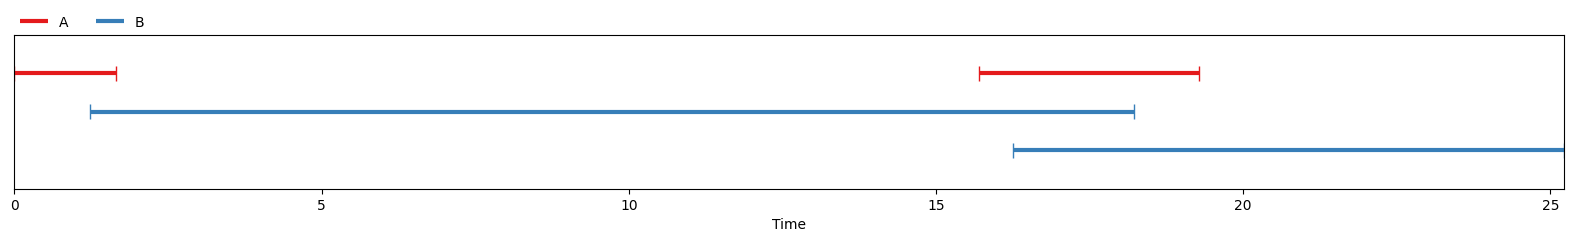

[0, 1.6600625, 'A']
[1.2345, 16.98, 'B']
[15.6968125, 3.58, 'A']
[16.256562499999998, 8.97, 'B']


In [5]:
audio, labels = data.artificial_diarisation_sample(speakers, max_secs=30, num_speakers=8,  interrupt_sec_mean=6, interrupt_var=.5)
print(audio.shape[-1]/16000)
visualise_annotation(labels)
print("\n".join(str(l) for l in labels))
play(audio, 16000)

0.0 ms
[[tensor(0.), tensor(1.6699), 'A'], [tensor(1.2305), tensor(16.9922), 'B'], [tensor(15.7031), tensor(3.5742), 'A'], [tensor(16.2598), tensor(8.9648), 'B']]


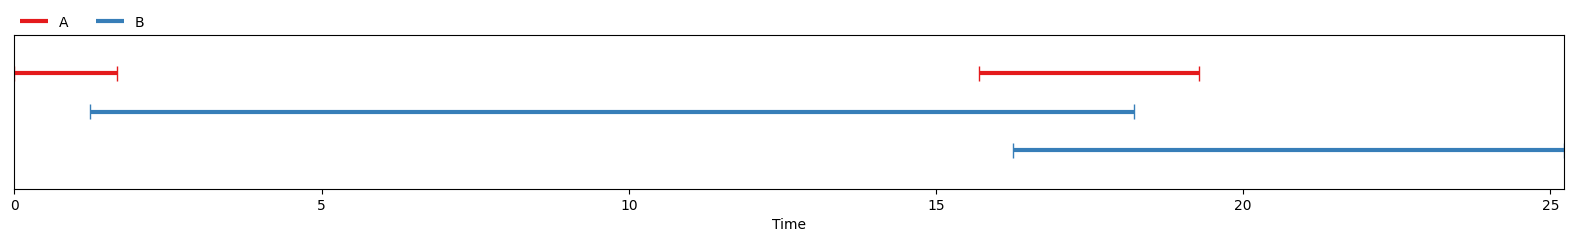

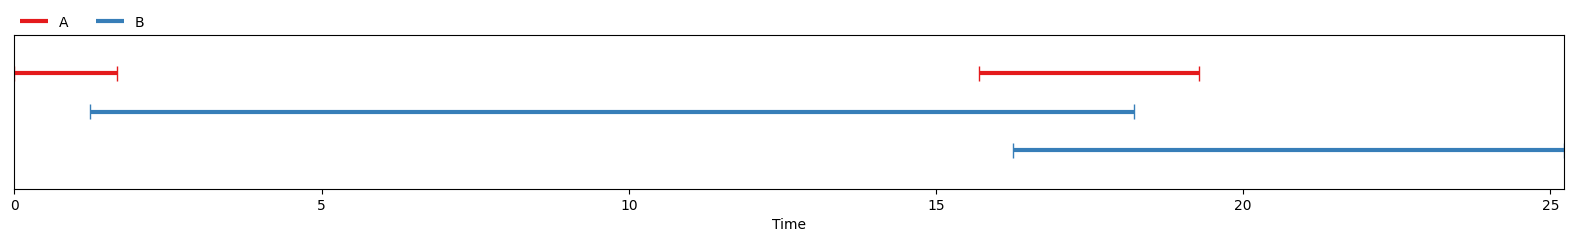

In [8]:
original = torch.tensor([[l[0], l[1]] for l in labels])
quantized = torch.round(original/max_seconds*num_tokens).int()
unquantized =  quantized*max_seconds/num_tokens 
avg_error = torch.mean(torch.abs(original - unquantized))
print(avg_error.item()*1000, "ms")

# Visualise these labels

print(labels)
from copy import deepcopy

new_labels = deepcopy(labels)

for i, l in enumerate(new_labels):
    l[0] = unquantized[i][0]
    l[1] = unquantized[i][1]


# Let's see whether we can see a difference just for good measuer
visualise_annotation(labels)
visualise_annotation(new_labels)

# Desired Error Loop

Given a tolerable error e, what is the number of tokens we can get away with:

In [14]:
max_seconds = 60
num_tokens = 2048

# ms
e = 50

def compute_avg_error(num_tokens, max_seconds):
    original = torch.rand(1, 10000)*max_seconds
    quantized = torch.round(original/max_seconds*num_tokens)
    avg_error = torch.mean(torch.abs(original - quantized*max_seconds/num_tokens))
    avg_error = avg_error.item()*1000
    print(num_tokens, max_seconds, "secs", avg_error, "ms")
    return avg_error
    

avg_error = compute_avg_error(num_tokens, max_seconds)
while avg_error < e:
    num_tokens -= 16
    avg_error = compute_avg_error(num_tokens, max_seconds)

2048 60 secs 7.3356619104743 ms
2032 60 secs 7.436823099851608 ms
2016 60 secs 7.435489445924759 ms
2000 60 secs 7.525494322180748 ms
1984 60 secs 7.590766996145248 ms
1968 60 secs 7.686595898121595 ms
1952 60 secs 7.638017181307077 ms
1936 60 secs 7.703517097979784 ms
1920 60 secs 7.7381073497235775 ms
1904 60 secs 7.851166650652885 ms
1888 60 secs 7.938492111861706 ms
1872 60 secs 7.951600477099419 ms
1856 60 secs 8.122368715703487 ms
1840 60 secs 8.18360410630703 ms
1824 60 secs 8.223865181207657 ms
1808 60 secs 8.374317549169064 ms
1792 60 secs 8.365267887711525 ms
1776 60 secs 8.385831490159035 ms
1760 60 secs 8.559267036616802 ms
1744 60 secs 8.596367202699184 ms
1728 60 secs 8.7312376126647 ms
1712 60 secs 8.761127479374409 ms
1696 60 secs 8.910760283470154 ms
1680 60 secs 8.917504921555519 ms
1664 60 secs 8.976262994110584 ms
1648 60 secs 9.101384319365025 ms
1632 60 secs 9.11994744092226 ms
1616 60 secs 9.20137669891119 ms
1600 60 secs 9.453089907765388 ms
1584 60 secs 9.43416